# Batch Summary Plotter
這是一個可以用來批次輸出所有 HDF5 檔案中 Summary Analysis (包含時間歷史與 Drop 值) 的 Notebook。
您可以在下方的 `設定` 區塊中指定要處理哪些 HDF5 檔案、需要輸出的圖表項目，以及字體大小。

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 加入 labquake_explorer 的路徑以便引入 DataManager
sys.path.append(r"C:\experiment\labquake_explorer_re")
from labquake_explorer.data.data_manager import DataManager

# 若需要分析工具
def _get_t_trig(ev):
    if isinstance(ev, dict):
        if 'event_time' in ev: return ev['event_time']
        if 'time' in ev and len(ev['time']) > 0: return ev['time'][0]
    return np.nan

def moving_average(a, n=3):
    if n <= 1: return a
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n


In [2]:
# ========= 1. 設定 (Configuration) =========

# 輸入的 HDF5 檔案清單
h5_files = [
    r"C:\experiment\1D\t0108\t0108.h5",
    r"C:\experiment\1D\t0110\t0110.h5"
    # 可以在此加入更多檔案，支援萬用字元或 os.walk 迴圈產生清單
]

# 輸出的圖檔資料夾
output_dir = r"C:\experiment\labquake_explorer_re\export h5\batch_summary_plots"
os.makedirs(output_dir, exist_ok=True)

# 欲繪製的子圖清單。支援：
# 'slip', 'mu', 'delta_tau', 'delta_mu', 'delta_slip', 'delta_lvdt', 'd_values', 'stiffness', 'slip_rate'
plots_to_show = ['mu', 'delta_tau', 'delta_mu']

# 圖片與字體設定
FIG_WIDTH = 10
FIG_HEIGHT_PER_PLOT = 2.5
FONT_SIZE_LABEL = 14
FONT_SIZE_TICK = 12
FONT_SIZE_TITLE = 16
LINE_WIDTH = 1.5

# 平滑設定
MU_SMOOTH_W = 500
LVDT_SMOOTH_W = 100

# 繪圖樣式套用
plt.rcParams.update({
    'font.size': FONT_SIZE_TICK,
    'axes.labelsize': FONT_SIZE_LABEL,
    'axes.titlesize': FONT_SIZE_TITLE,
    'lines.linewidth': LINE_WIDTH,
})


In [3]:
# ========= 2. 核心繪圖函數 =========

def extract_analysis_results(events):
    """從 events 中提取分析結果(如 delta_tau, delta_mu 等)"""
    results = {}
    keys_to_extract = ['delta_tau', 'delta_mu', 'delta_lvdt', 'D_Push', 'D_max', 'D_E3', 'D_E4', 'skipped', 'k']
    
    # 偵測動態鍵名 (E1_value等)
    for ev in events:
        if isinstance(ev, dict) and 'delta' in ev:
            keys_to_extract.extend([k for k in ev['delta'].keys() if k.endswith('_value')])
            break
            
    for k in keys_to_extract:
        arr = []
        for ev in events:
            if not isinstance(ev, dict):
                arr.append(np.nan)
                continue
            if k == 'delta_tau':
                arr.append(ev.get('tau', {}).get('value', np.nan))
            elif k == 'delta_lvdt':
                arr.append(ev.get('lvdt', {}).get('value', np.nan))
            elif k == 'k':
                k_obj = ev.get('k', np.nan)
                arr.append(k_obj.get('value', np.nan) if isinstance(k_obj, dict) else k_obj)
            elif k.endswith('_value') and k.startswith('E'): 
                arr.append(ev.get('delta', {}).get(k, np.nan))
            else:
                arr.append(ev.get(k, np.nan))
        
        final_key = f'delta_{k.split("_")[0]}' if k.endswith('_value') else k
        results[final_key] = np.array(arr)
        
    if 'skipped' in results:
        results['skipped'] = np.array([bool(x) if not np.isnan(x) else False for x in results['skipped']])
        
    return results

def plot_run_summary(run_data, run_name, filepath):
    """繪製單一 run 的 summary，並回傳 figure 物件"""
    time_history = run_data.get('time history', {})
    events = run_data.get('events', [])
    
    if not time_history or 'time' not in time_history or not events:
        print(f"[{run_name}] 無效的 time_history 或 events 資料，跳過。")
        return None
        
    results = extract_analysis_results(events)
    
    trigger_times = []
    for ev in events:
        t = _get_t_trig(ev)
        trigger_times.append(t if t is not None else np.nan)
    trigger_times = np.array(trigger_times)
    
    # 決定時間範圍 (從第一個有效 event 到最後一個)
    valid_trigs = trigger_times[~np.isnan(trigger_times)]
    if len(valid_trigs) == 0:
        return None
    t_start, t_end = valid_trigs[0], valid_trigs[-1]
    
    t_all = time_history['time']
    t_plot_start = t_start - 1.0
    t_plot_end = t_end + 5.0
    mask = (t_all >= t_plot_start) & (t_all <= t_plot_end)
    t_mask = t_all[mask]
    if len(t_mask) == 0: return None
    
    t_offset = t_mask[0]
    t_plot = t_mask - t_offset
    
    # 初始化畫布
    n = len(plots_to_show)
    fig, axs = plt.subplots(n, 1, figsize=(FIG_WIDTH, max(4, FIG_HEIGHT_PER_PLOT * n)), sharex=True, dpi=150)
    if n == 1: axs = [axs]
    
    axs_map = dict(zip(plots_to_show, axs))
    
    def _get_analysis_in_range(key):
        if key not in results: return None, None
        arr = results[key]
        trigs = trigger_times
        valid_mask = np.ones(len(trigs), dtype=bool)
        valid_mask[0] = False # Ignore event 0
        range_mask = valid_mask & ~np.isnan(trigs) & (trigs >= t_plot_start - 1) & (trigs <= t_plot_end + 1)
        if 'skipped' in results:
            range_mask &= ~results['skipped']
        return trigs[range_mask] - t_offset, arr[range_mask]

    def _add_trigger_lines(ax):
        t_end_ext = t_end + (t_end - t_start) * 0.01
        for i, tr_time in enumerate(trigger_times):
            if t_start <= tr_time <= t_end_ext:
                tr = tr_time - t_offset
                ax.axvline(x=tr, color='gray', linestyle=':', alpha=0.3, linewidth=0.8)

    # --- Plot Data ---
    for key, ax in axs_map.items():
        ax.grid(True, linestyle='-', alpha=0.3)
        _add_trigger_lines(ax)
        
        if key == 'mu':
            if 'mu' in time_history:
                mu_data = time_history['mu'][mask]
                mu_sm = moving_average(mu_data, max(1, MU_SMOOTH_W))
                if len(mu_sm) < len(t_plot):
                    mu_sm = np.pad(mu_sm, (0, len(t_plot) - len(mu_sm)), 'edge')
                ax.plot(t_plot, mu_sm, 'k')
            ax.set_ylabel(r'$\mu$')
            
        elif key == 'slip':
            if 'LP_displacement' in time_history:
                lvdt_raw = time_history['LP_displacement'][mask]
                lvdt_sm = moving_average(lvdt_raw, max(1, LVDT_SMOOTH_W))
                if len(lvdt_sm) < len(t_plot):
                    lvdt_sm = np.pad(lvdt_sm, (0, len(t_plot) - len(lvdt_sm)), 'edge')
                lvdt_0 = lvdt_sm - lvdt_sm[0]
                ax.plot(t_plot, lvdt_0, 'gray', label='LVDT', alpha=0.5)
            eddy_keys = sorted([k for k in time_history.keys() if 'eddy' in k.lower()])
            for i, k in enumerate(eddy_keys):
                e_0 = time_history[k][mask] - time_history[k][mask][0]
                ax.plot(t_plot, e_0, label=f'E{i+1}', alpha=0.7)
            ax.set_ylabel('slip [μm]')
            ax.legend(loc='upper left', fontsize='small')

        elif key == 'delta_tau':
            t_r, vals = _get_analysis_in_range('delta_tau')
            if t_r is not None:
                valid = ~np.isnan(vals)
                ax.plot(t_r[valid], vals[valid], 'o-', markersize=4)
            ax.set_ylabel(r'$\Delta\tau$ [MPa]')

        elif key == 'delta_mu':
            t_r, vals = _get_analysis_in_range('delta_mu')
            if t_r is not None:
                valid = ~np.isnan(vals)
                ax.plot(t_r[valid], vals[valid], 'o-', markersize=4, color='darkorange')
            ax.set_ylabel(r'$\Delta\mu$')
            
        elif key == 'delta_slip':
            eddy_keys = sorted([k for k in time_history.keys() if 'eddy' in k.lower()])
            for i in range(len(eddy_keys)):
                label = f'delta_E{i+1}'
                t_r, vals = _get_analysis_in_range(label)
                if t_r is not None:
                    valid = ~np.isnan(vals)
                    ax.plot(t_r[valid], vals[valid], 'o-', alpha=0.7, markersize=4, label=f'E{i+1}')
            ax.legend(loc='upper left', fontsize='small')
            ax.set_ylabel(r'$\Delta$ Slip [μm]')

        elif key == 'delta_lvdt':
            t_r, vals = _get_analysis_in_range('delta_lvdt')
            if t_r is not None:
                valid = ~np.isnan(vals)
                ax.plot(t_r[valid], vals[valid], 'o-', color='slategrey', markersize=4)
            ax.set_ylabel(r'$\Delta$ LVDT [μm]')

        elif key == 'd_values':
            for dkey, color, label in [('D_Push', 'teal', r'$D_{Push}$'), ('D_max', 'coral', r'$D_{max}$'), ('D_E4', None, r'$D_{E3}$')]:
                t_r, vals = _get_analysis_in_range(dkey)
                if t_r is not None:
                    valid = ~np.isnan(vals)
                    kwargs = {'markersize': 4, 'alpha': 0.8, 'label': label}
                    if color: kwargs['color'] = color
                    ax.plot(t_r[valid], vals[valid], 'o-', **kwargs)
            ax.legend(loc='upper left', fontsize='small')
            ax.set_ylabel(r'D [μm]')
            
        elif key == 'stiffness':
            t_r, vals = _get_analysis_in_range('k')
            if t_r is not None:
                valid = ~np.isnan(vals)
                ax.plot(t_r[valid], vals[valid], 'o-', color='teal', markersize=4)
            ax.set_ylabel('k [MPa/μm]')
            
        elif key == 'slip_rate':
            eddy_keys = sorted([k for k in time_history.keys() if k.startswith('eddy_ch')])
            hr_group = time_history.get('high_rate_sliprates', {})
            for i, ek in enumerate(eddy_keys):
                ch_num = ek.replace('eddy_ch', '')
                t_rate_key = f't_sliprate_ch{ch_num}'
                rate_key = f'sliprate_ch{ch_num}'
                all_t_parts, all_r_parts = [], []
                
                if t_rate_key in time_history and rate_key in time_history:
                    t_sr = time_history[t_rate_key]
                    r_sr = time_history[rate_key]
                    sr_mask = (t_sr >= t_plot_start) & (t_sr <= t_plot_end)
                    if np.sum(sr_mask) > 0:
                        all_t_parts.append(t_sr[sr_mask] - t_offset)
                        all_r_parts.append(r_sr[sr_mask])
                        
                blk_idx = 2
                while True:
                    hr_t_name = f't_high_sliprate_ch{ch_num}_blk{blk_idx}'
                    hr_r_name = f'high_sliprate_ch{ch_num}_blk{blk_idx}'
                    t_hr = hr_group.get(hr_t_name) if isinstance(hr_group, dict) else hr_group.get(hr_t_name)
                    r_hr = hr_group.get(hr_r_name) if isinstance(hr_group, dict) else hr_group.get(hr_r_name)
                    if t_hr is None:
                        t_hr = time_history.get(hr_t_name)
                        r_hr = time_history.get(hr_r_name)
                    if t_hr is None: break
                    hr_mask = (t_hr >= t_plot_start) & (t_hr <= t_plot_end)
                    if np.sum(hr_mask) > 0:
                        all_t_parts.append(t_hr[hr_mask] - t_offset)
                        all_r_parts.append(r_hr[hr_mask])
                    blk_idx += 1
                
                if all_t_parts:
                    combined_t = np.concatenate(all_t_parts)
                    combined_r = np.concatenate(all_r_parts)
                    idx_sort = np.argsort(combined_t)
                    ax.plot(combined_t[idx_sort], combined_r[idx_sort], color=f'C{i}', alpha=0.7, label=f'E{i+1}')
            ax.legend(loc='upper left', fontsize='small')
            ax.set_yscale('log')
            ax.set_ylim(1e-2, 3e5)
            ax.set_ylabel('Rate [μm/s]')

    axs[-1].set_xlabel('Time [s]')
    axs[-1].set_xlim([t_plot[0], t_plot[-1]])
    
    fig.suptitle(run_name, fontweight='bold', fontsize=FONT_SIZE_TITLE)
    fig.tight_layout()
    return fig


正在載入: t0108.h5 ...
Legacy data structure migrated to new nested timeline structure.
  > 繪製 run1_16MPa ...


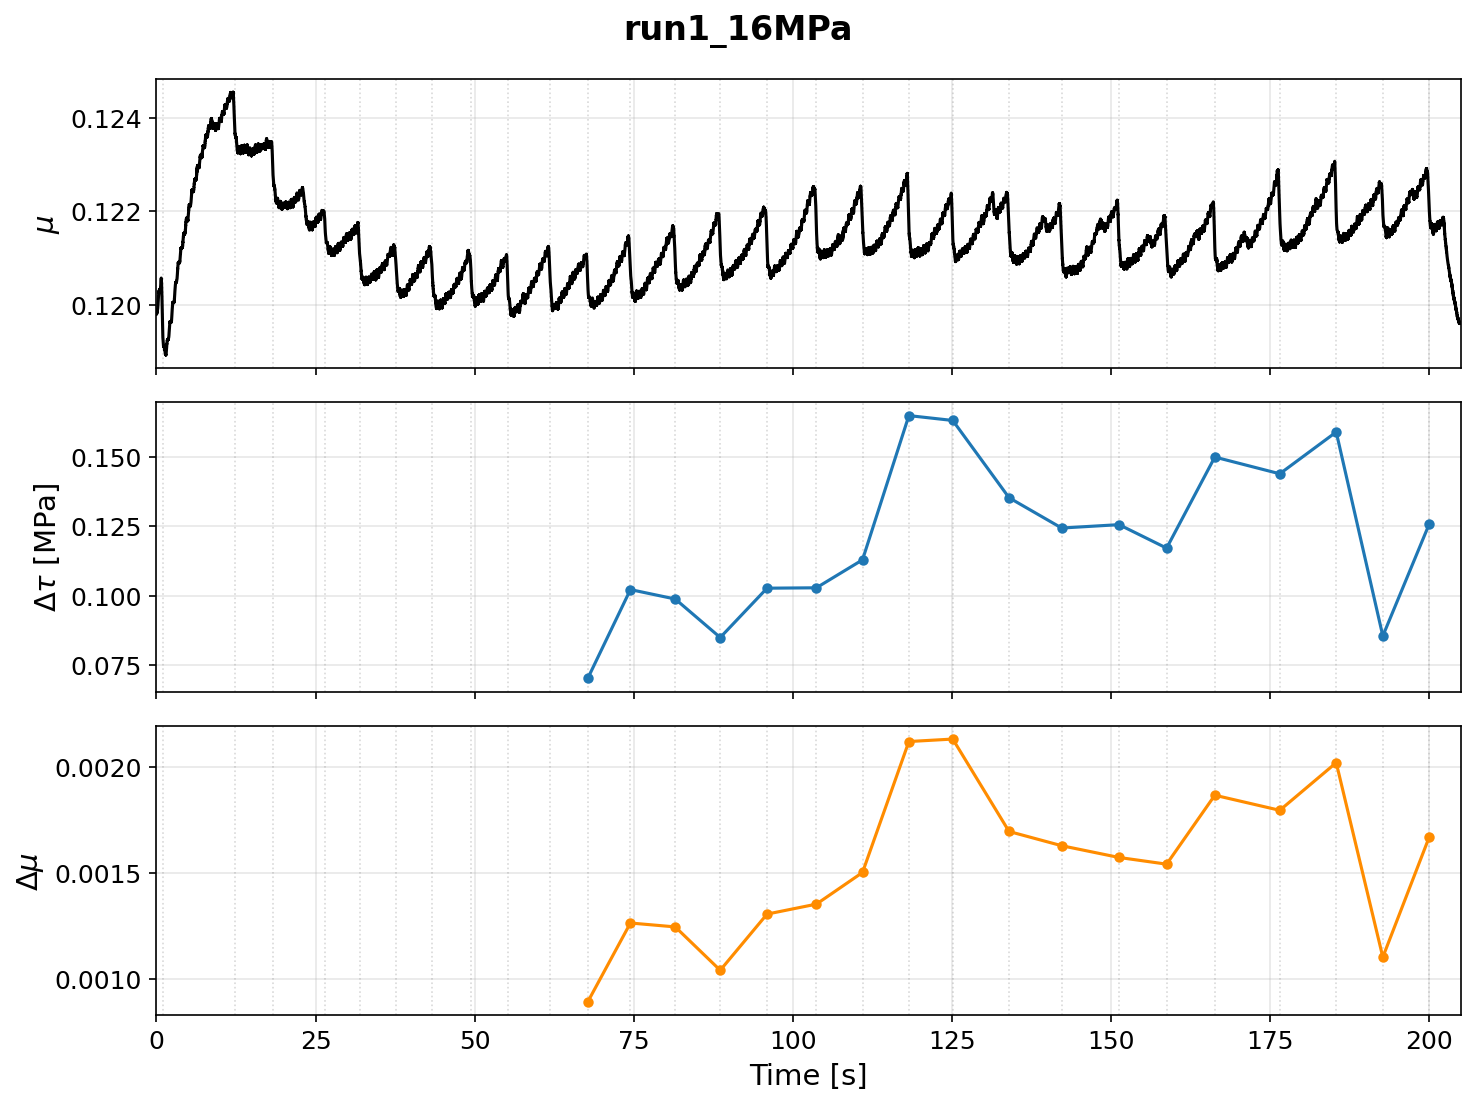

    [儲存成功] t0108_run1_16MPa.png
  > 繪製 run2_14MPa ...


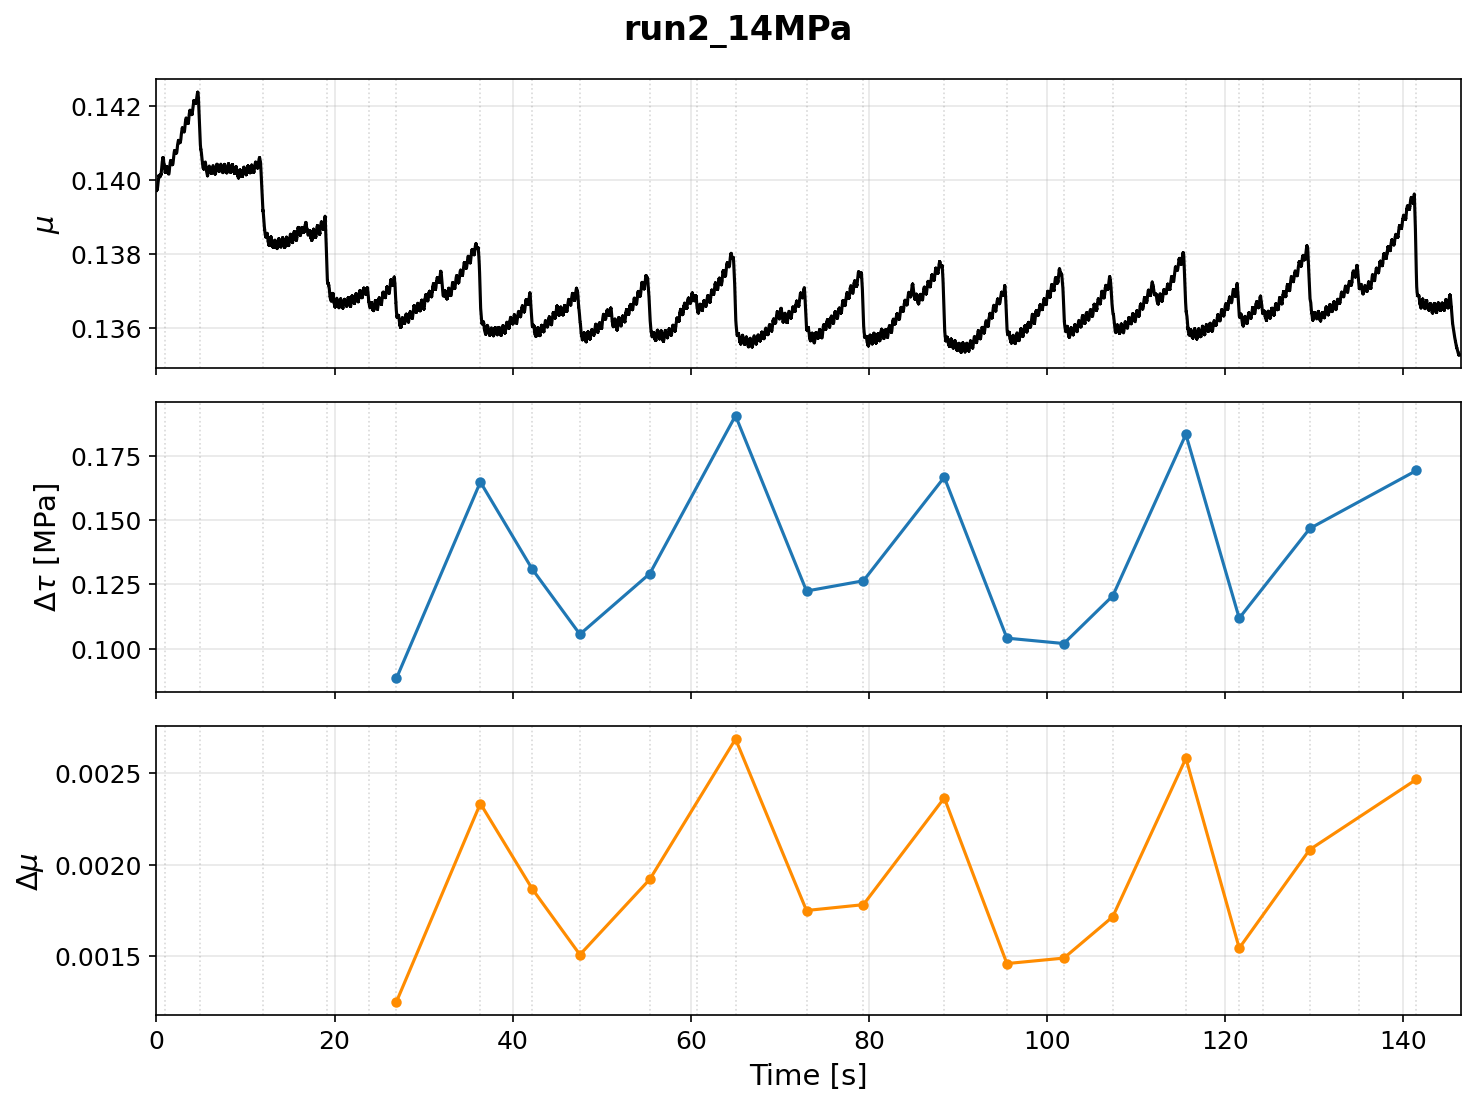

    [儲存成功] t0108_run2_14MPa.png
  > 繪製 run3_12MPa ...


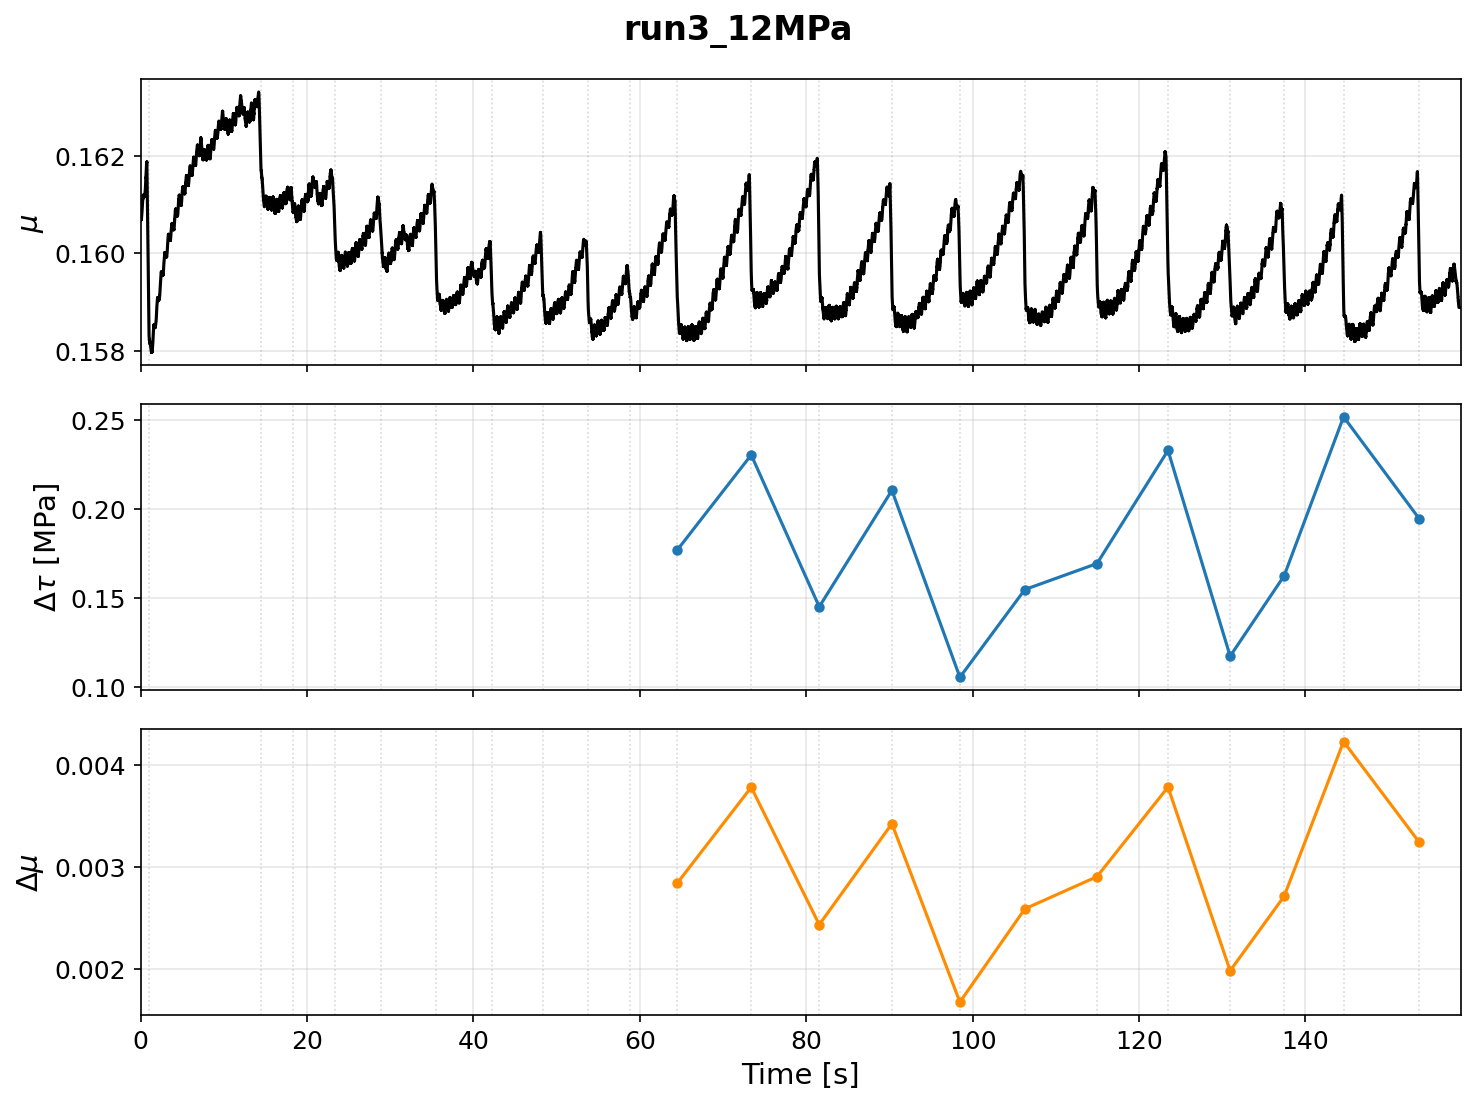

    [儲存成功] t0108_run3_12MPa.png
  > 繪製 run4_10MPa ...


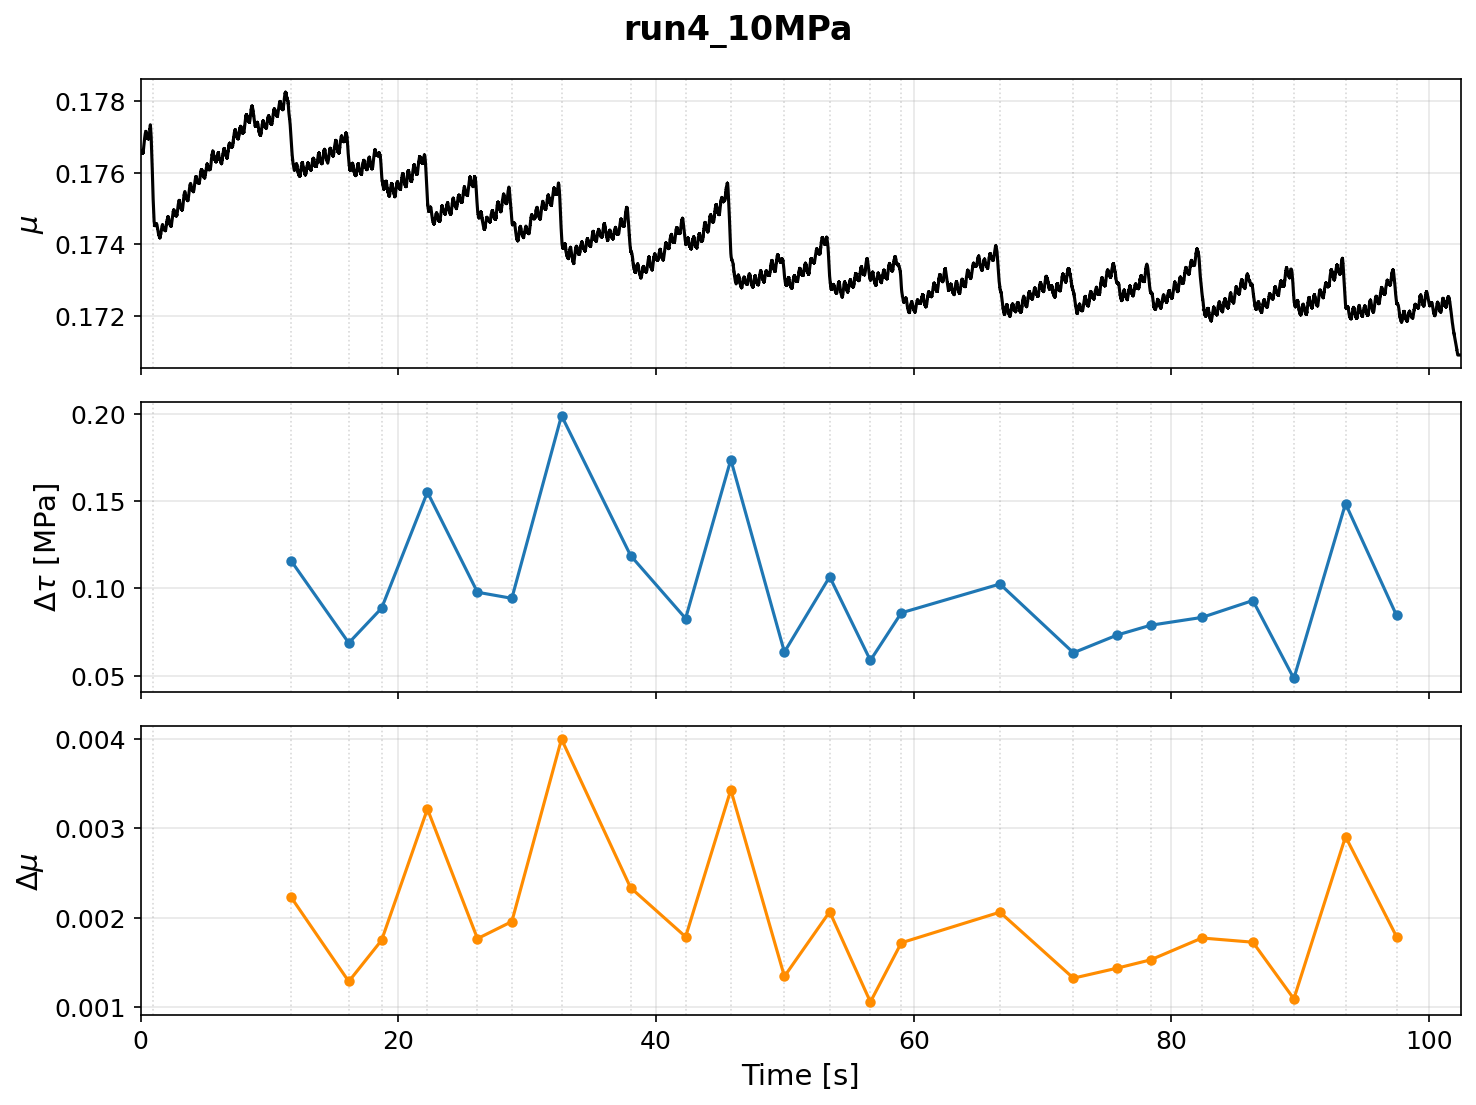

    [儲存成功] t0108_run4_10MPa.png
正在載入: t0110.h5 ...
  > 繪製 run1_16MPa ...


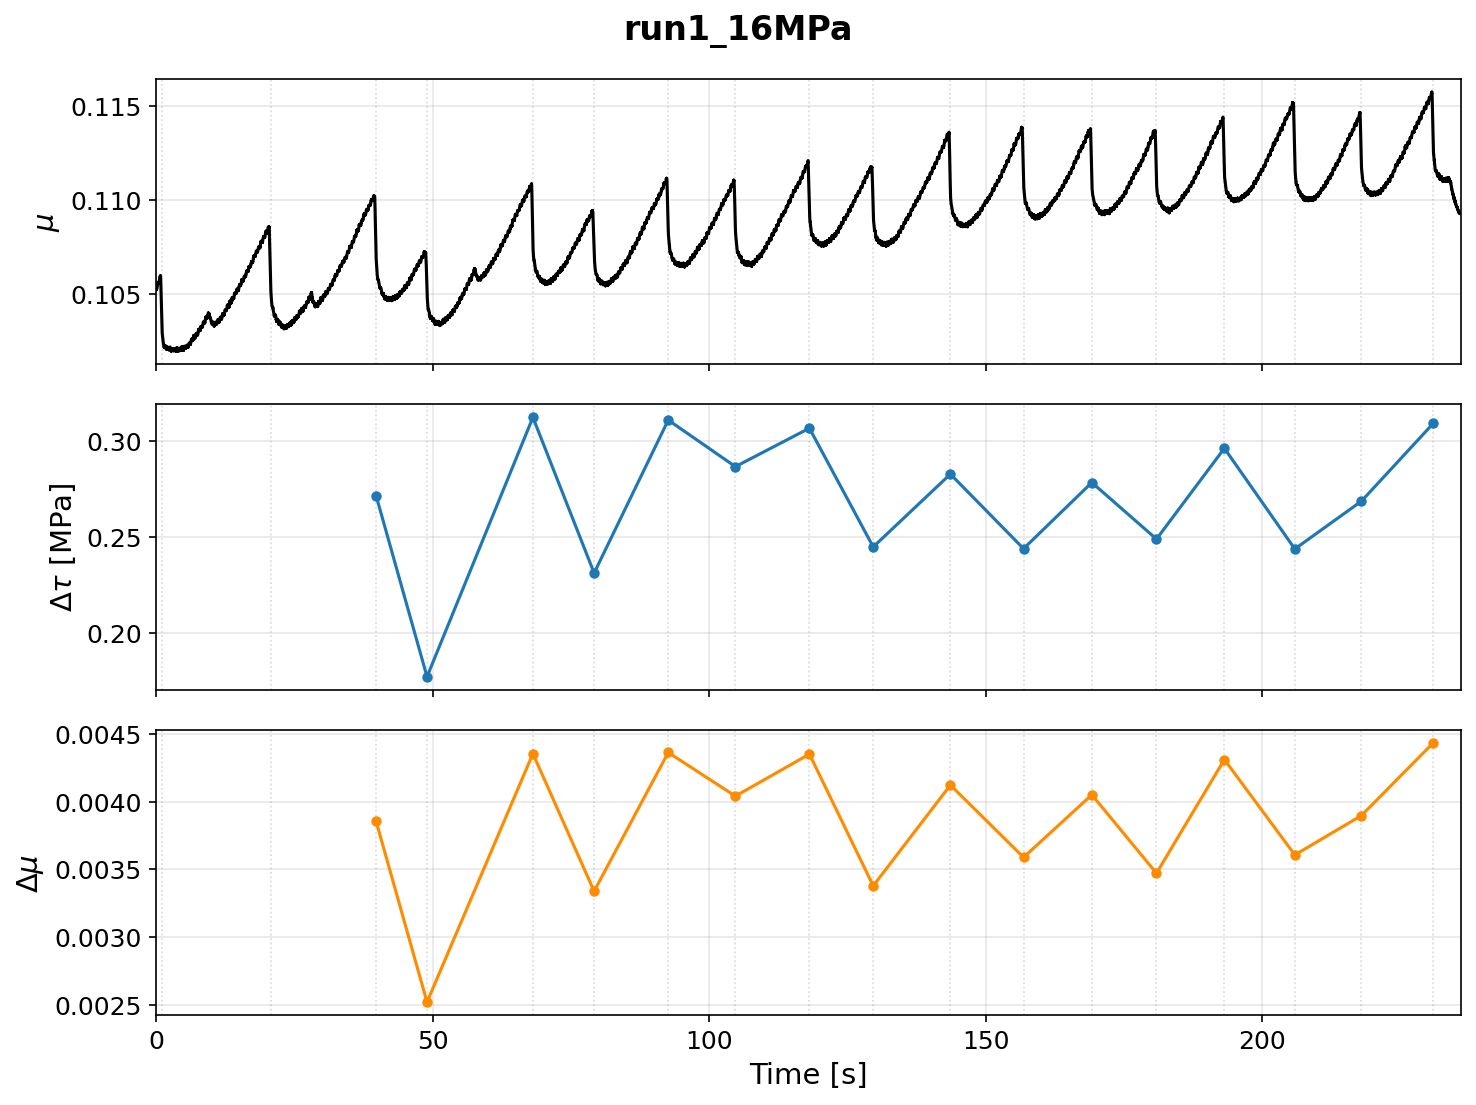

    [儲存成功] t0110_run1_16MPa.png
  > 繪製 run2_14MPa ...


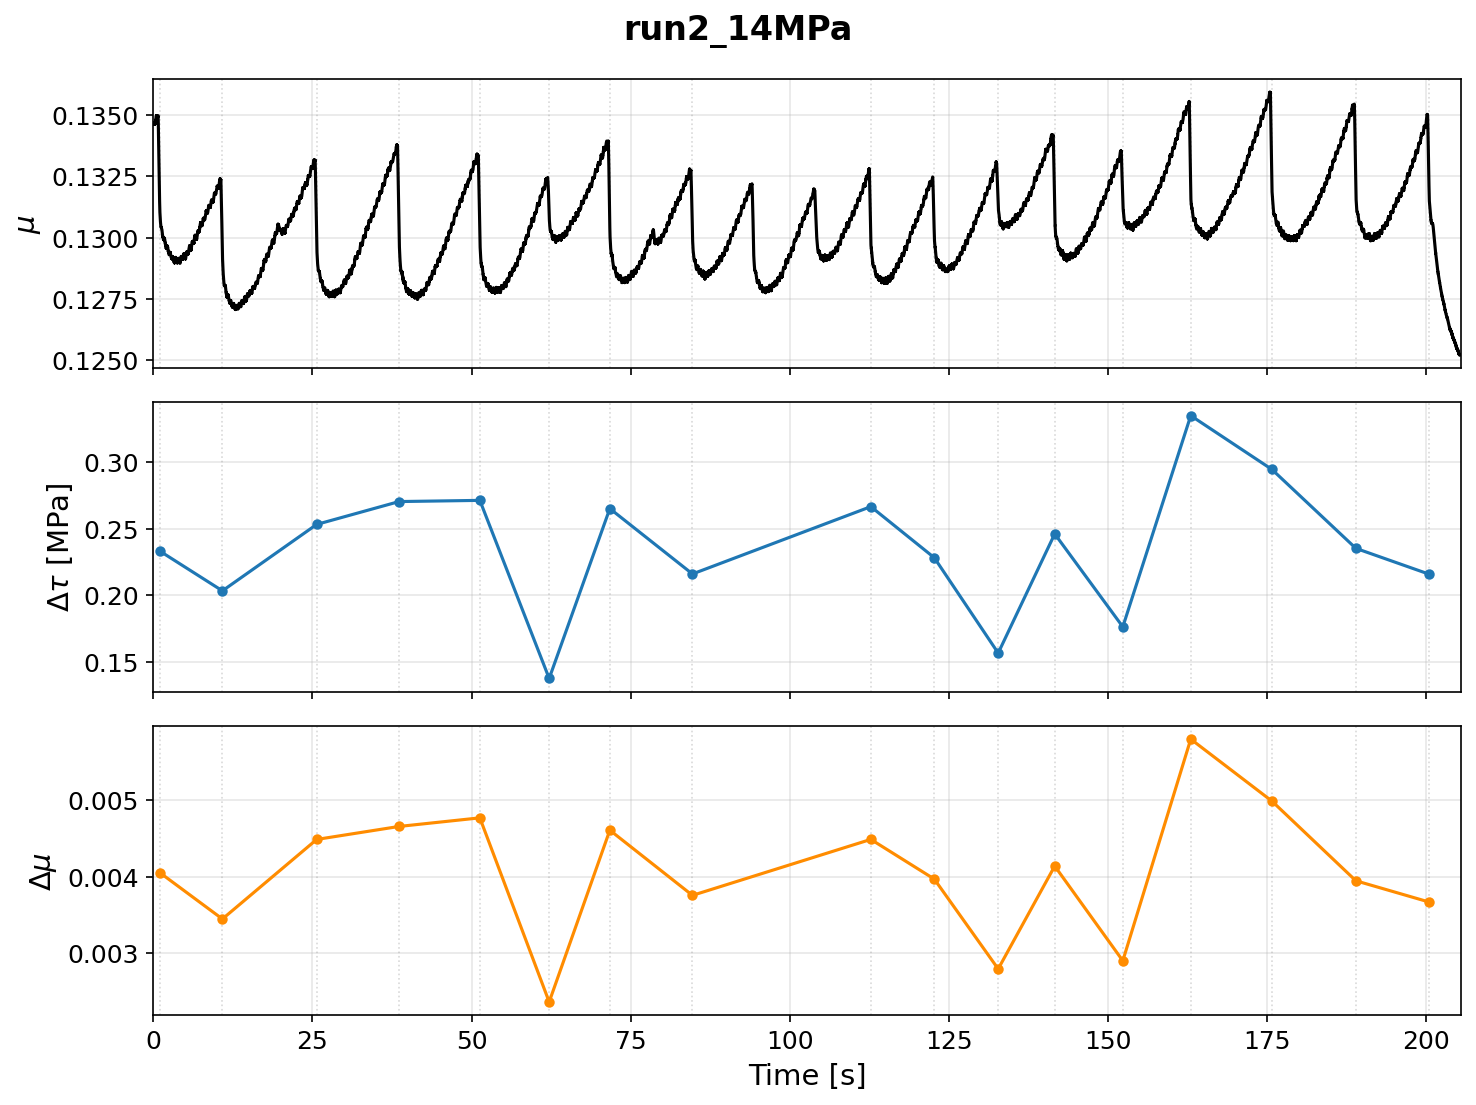

    [儲存成功] t0110_run2_14MPa.png
  > 繪製 run3_12MPa ...


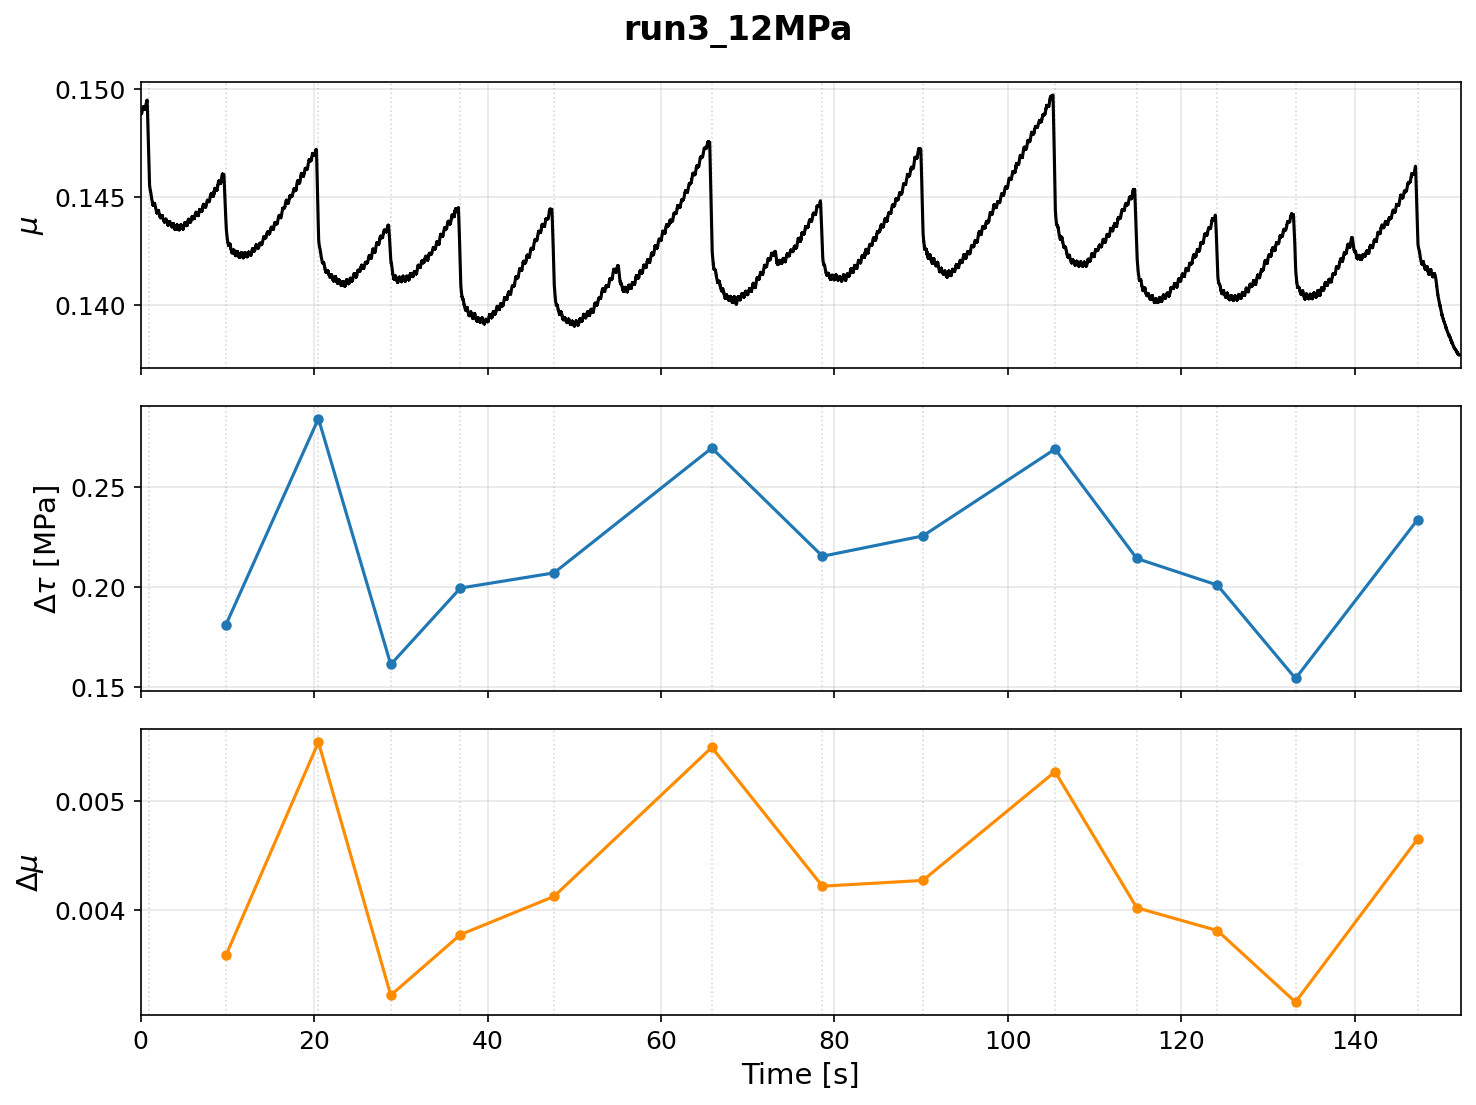

    [儲存成功] t0110_run3_12MPa.png
  > 繪製 run4_10MPa ...


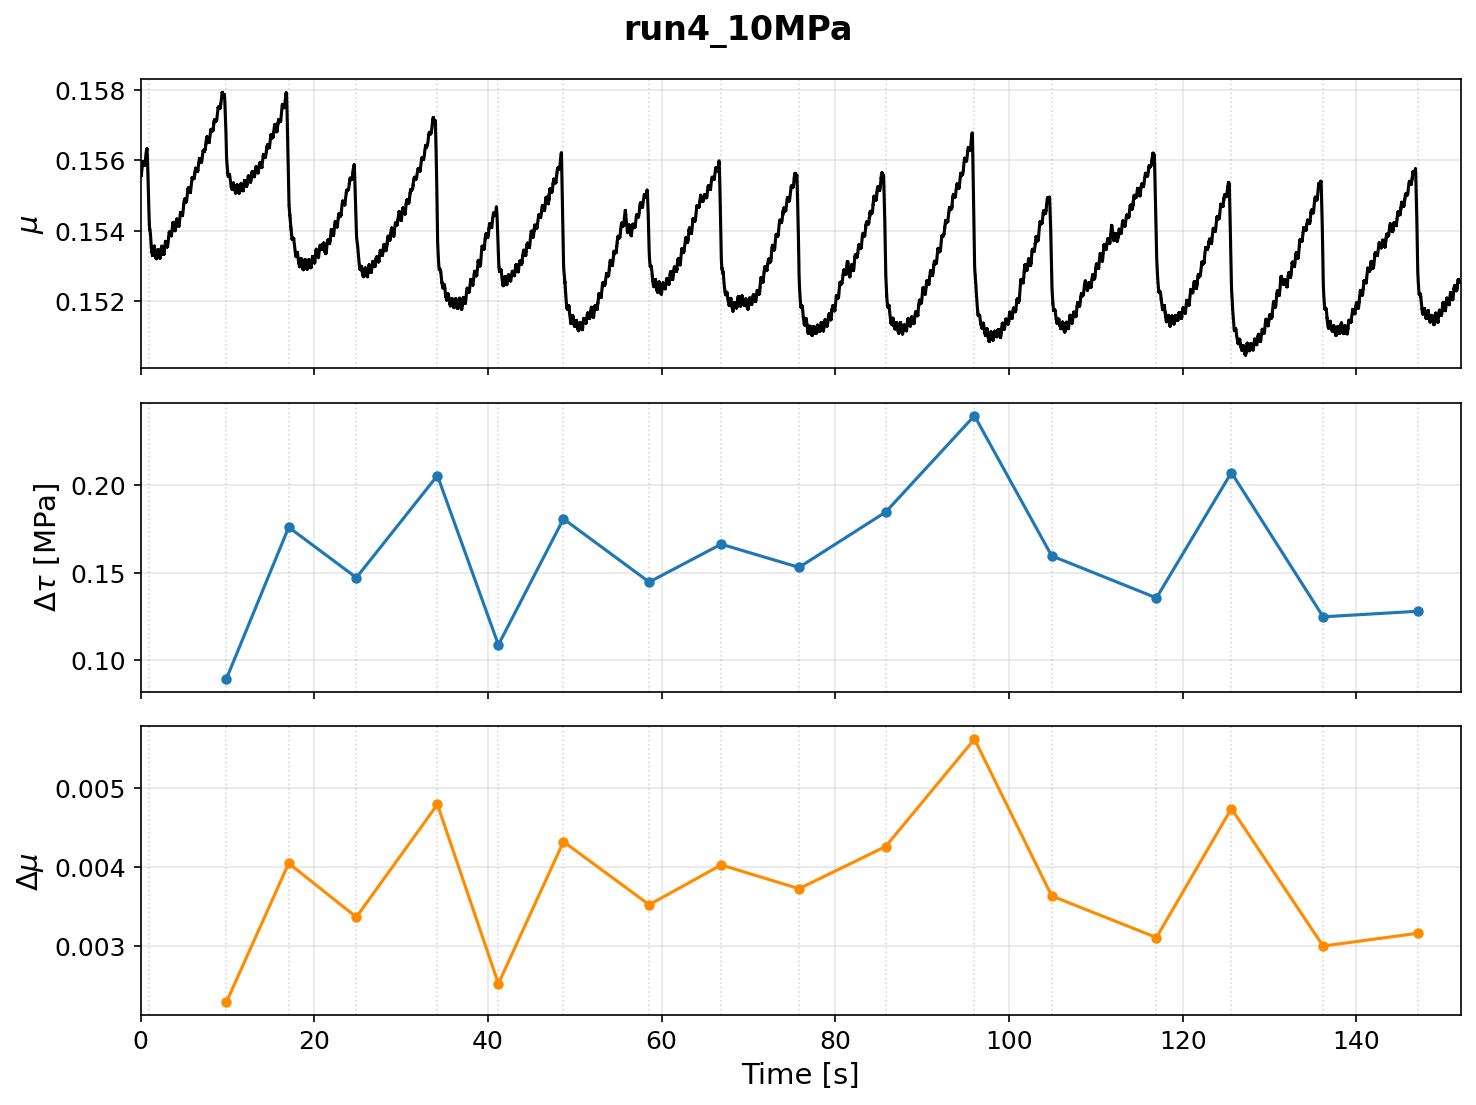

    [儲存成功] t0110_run4_10MPa.png


In [4]:
# ========= 3. 批次處理與存檔 =========

manager = DataManager()

for fpath in h5_files:
    file_path = Path(fpath)
    if not file_path.exists():
        print(f"檔案不存在，跳過: {file_path}")
        continue
        
    print(f"正在載入: {file_path.name} ...")
    manager.load_file(file_path)
    data = manager.data
    
    if not data or 'runs' not in data:
        print("查無 runs 資料。")
        continue
        
    runs = data['runs']
    if isinstance(runs, list):
        runs_items = enumerate(runs)
    elif isinstance(runs, dict):
        runs_items = runs.items()
    else:
        continue
        
    for run_idx, run_data in runs_items:
        if not isinstance(run_data, dict): continue
        
        run_name = run_data.get('name', f"Run_{run_idx}")
        print(f"  > 繪製 {run_name} ...")
        
        fig = plot_run_summary(run_data, run_name, file_path.name)
        
        if fig is not None:
            # 存檔名稱: 檔名_Run名.png
            save_name = f"{file_path.stem}_{run_name}.png"
            save_path = os.path.join(output_dir, save_name)
            
            # 存檔
            fig.savefig(save_path, bbox_inches='tight')
            # 顯示於 Notebook (若不需顯示可註解下行)
            plt.show()
            plt.close(fig)
            print(f"    [儲存成功] {save_name}")
